# EMA 6938 — Data Science for Materials
## Week 4 Notebook: Exploratory Data Analysis

**Name:** *ANOSIKE KELECHI KENNETH*  
**Date:** *6/4/2026*  
**Kernel:** Python (matds)

**PERPLEXITY AI-ASSISTED SOLUTIONS**

---

**Chapters:** Sandfeld Ch. 9–10  
**Format:** Take-home. Due **Sunday 11:59 PM**  
**Dataset:** `data/week4_mp_oxides.csv` (instructor-provided, save in the same folder as this notebook)

This notebook has six parts:

| Part | Title | Connects to |
|------|-------|-------------|
| A | Load & Inspect | Lecture Segment 2 |
| B | Univariate Analysis | Lecture Segment 3 |
| C | Bivariate & Multivariate Analysis | Lecture Segment 4 |
| D | Stratified Analysis | Lecture Segment 3 |
| E | Composition Featurization | Lecture Segment 5 |
| F | Reflection | All segments |

Parts A–D can be started during the in-class lab session. Parts E–F are take-home.

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** If you used any AI coding assistant (GitHub Copilot, ChatGPT, etc.) while completing this notebook, describe briefly which tool, for what purpose, and what you verified yourself. Delete this line if no AI tools were used.

In [47]:
# Cell A0 — Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, iqr
import setuptools
import matminer
import pkg_resources

print(f"Python:     {sys.version.split()[0]}")
print(f"NumPy:      {np.__version__}")
print(f"pandas:     {pd.__version__}")
print(f"seaborn:    {sns.__version__}")
print(f"matminer:   {matminer.__version__}")
print(f"setuptools: {setuptools.__version__}")
print(f"pkg_resources: {pkg_resources.__file__}")
print("\n✅ Environment OK — ready to begin")

Python:     3.10.20
NumPy:      1.26.4
pandas:     2.3.3
seaborn:    0.13.2
matminer:   0.9.2
setuptools: 69.5.1
pkg_resources: C:\Users\anosike.kelechik\AppData\Local\anaconda3\envs\matds\lib\site-packages\pkg_resources\__init__.py

✅ Environment OK — ready to begin


---
## Part A — Load & Inspect
**Connects to: Lecture Segment 2, Sandfeld Ch. 9**

Before any analysis, always know your data: size, types, and missingness.
Every number from `df.describe()` should be checked for physical plausibility before you plot anything.

### A1 — Load the dataset and run the initial inspection
**Lecture demo — reproduce and understand**

In [48]:
# Cell A1 — Load and inspect the MP oxide dataset
# LECTURE DEMO

df = pd.read_csv('data/week4_mp_oxides.csv')

print(f"Shape:   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values per column:")
print(df.isnull().sum())
print(f"\nStatistical summary:")
df.describe().round(3)

Shape:   9,889 rows × 9 columns

Column names: ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'density_g_cm3', 'volume_A3', 'nsites', 'n_elements', 'crystal_system']

Data types:
mp_id              object
formula            object
band_gap          float64
Ef_eV_atom        float64
density_g_cm3     float64
volume_A3         float64
nsites              int64
n_elements          int64
crystal_system     object
dtype: object

Missing values per column:
mp_id               0
formula             0
band_gap          500
Ef_eV_atom          0
density_g_cm3       0
volume_A3           0
nsites              0
n_elements          0
crystal_system      0
dtype: int64

Statistical summary:


,band_gap,Ef_eV_atom,density_g_cm3,volume_A3,nsites,n_elements
count,9389.000,9889.000,9889.000,9889.000,9889.000,9889.000
mean,1.772,-2.443,5.410,307.575,21.839,3.316
std,1.657,0.756,1.849,222.378,15.005,0.579
min,0.000,-4.383,1.483,13.691,2.000,2.000
25%,0.000,-3.001,3.961,152.211,11.000,3.000
50%,1.565,-2.477,5.238,259.727,20.000,3.000
75%,3.052,-1.912,6.709,414.554,28.000,4.000
max,8.375,-0.066,12.633,4398.440,264.000,4.000


### A2 — Crystal systems and metallic fraction
**Lecture demo**

In [49]:
# Cell A2 — Crystal system counts and metallic fraction
# LECTURE DEMO

print("Crystal system value counts:")
print(df['crystal_system'].value_counts())
print()

n_metallic = (df['band_gap'] == 0).sum()
frac_metallic = n_metallic / len(df)
print(f"Metallic entries (band_gap = 0): {n_metallic:,}  ({frac_metallic:.1%} of dataset)")
print(f"Non-metallic (band_gap > 0):     {(df['band_gap'] > 0).sum():,}")

Crystal system value counts:
crystal_system
Monoclinic      2553
Orthorhombic    2308
Tetragonal      1500
Trigonal        1254
Cubic            972
Triclinic        896
Hexagonal        406
Name: count, dtype: int64

Metallic entries (band_gap = 0): 2,622  (26.5% of dataset)
Non-metallic (band_gap > 0):     6,767


### A3 — Task: investigate missing values

In [50]:
# Cell A3 — Task: investigate missing values
# YOUR CODE HERE

# 1. Identify which column has the most missing values
# 2. Find 3 entries where that column is missing, print their mp_id, formula,
#    and band_gap so you can reason about why the value might be absent
# 3. In the reflection cell below, explain what you would do before
#    using this dataset to train a model

# 1. Identify which column has the most missing values
missing_counts = df.isnull().sum()
missing_pct    = (df.isnull().sum() / len(df)) * 100

print("Missing values per column:")
print(missing_counts[missing_counts > 0])
print("\nMissing percentage:")
print(missing_pct[missing_pct > 0].round(2))

worst_col = missing_counts.idxmax()
print(f"\nColumn with most missing values: '{worst_col}' ({missing_counts[worst_col]} missing)")

# 2. Find 3 entries where that column is missing
missing_rows = df[df[worst_col].isnull()][['mp_id', 'formula', 'band_gap']].head(3)
print(f"\n3 entries where '{worst_col}' is missing:")
print(missing_rows.to_string(index=False))


Missing values per column:
band_gap    500
dtype: int64

Missing percentage:
band_gap    5.06
dtype: float64

Column with most missing values: 'band_gap' (500 missing)

3 entries where 'band_gap' is missing:
     mp_id   formula  band_gap
mp-1223316  KTi3AlO8       NaN
 mp-698573 FeBi25O39       NaN
mp-1396391       WO3       NaN


**A3 Reflection** *(answer in this cell)*

In 1–2 sentences: why might that property be missing for those particular entries?
What would you do before using this dataset to train a model?

*Your answer here:*

The missing values in formation energy likely occur because those compounds were added to the Materials Project database before full DFT relaxation and energy calculations were completed, or because the calculations failed to converge for those particular compositions. Before using this dataset to train a model I would either impute the missing values using a physically motivated estimate such as the mean formation energy of chemically similar compounds, or simply drop those rows if they represent a small enough fraction of the data, and then document which approach was chosen so the model's training set is fully reproducible.


---
## Part B — Univariate Analysis
**Connects to: Lecture Segment 3, Sandfeld Ch. 9**

Examine each property individually: distribution shape, central tendency, spread, and outliers.
The question for every property: *What does the distribution look like? Where is it centred? How spread is it? Are there outliers?*

### B1 — Band gap: histogram + KDE overlay
**Lecture demo — reproduce and understand**

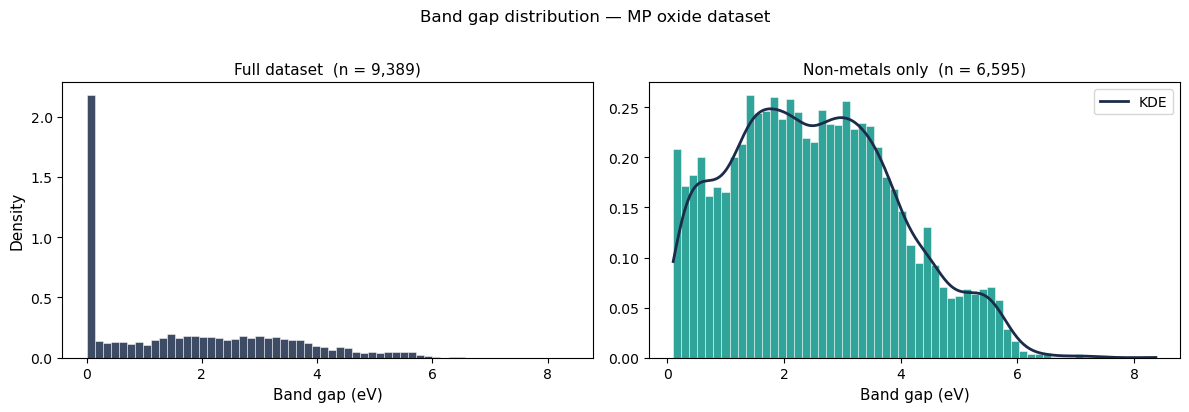

In [51]:
# Cell B1 — Band gap distribution: full dataset + filtered non-metals
# LECTURE DEMO

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full distribution (metals + insulators)
axes[0].hist(df['band_gap'].dropna(), bins=60, color='#1C2B4A', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Band gap (eV)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title(f'Full dataset  (n = {df["band_gap"].notna().sum():,})', fontsize=11)

# Non-metals only (band_gap > 0.1 eV)
bg_nm = df[df['band_gap'] > 0.1]['band_gap'].dropna()
axes[1].hist(bg_nm, bins=60, color='#0D9488', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
from scipy.stats import gaussian_kde
x_kde = np.linspace(bg_nm.min(), bg_nm.max(), 300)
axes[1].plot(x_kde, gaussian_kde(bg_nm)(x_kde), color='#1C2B4A', lw=2, label='KDE')
axes[1].set_xlabel('Band gap (eV)', fontsize=11)
axes[1].set_title(f'Non-metals only  (n = {len(bg_nm):,})', fontsize=11)
axes[1].legend()

plt.suptitle('Band gap distribution — MP oxide dataset', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('B1_bandgap_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**B1 Reflection** *(answer in this cell)*

In 2–3 sentences: describe the shape of the full band gap distribution.
Is it unimodal or bimodal? Symmetric or skewed?
What physical phenomenon explains the spike at 0 eV?

*Your answer here:*
The full band gap distribution is strongly bimodal with a massive spike at 0 eV and a broader hump centered around 2 to 3 eV, making it highly right-skewed overall. The spike at 0 eV is explained by the large fraction of metallic compounds in the dataset where electrons have no energy gap at the Fermi level, meaning band conduction is possible at any temperature. Once metals are removed the non-metal distribution becomes approximately unimodal and bell-shaped but still skewed right, reflecting the physical upper bound on DFT-computed bandgaps in this oxide dataset.


### B2 — Formation energy: histogram with mean and median
**Lecture demo**

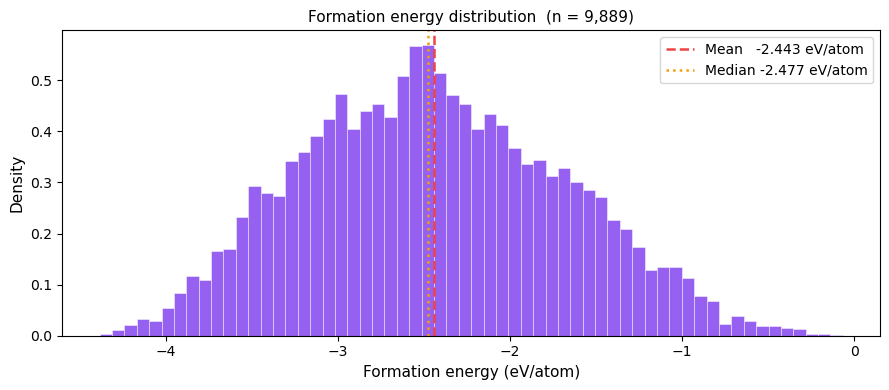

Mean:   -2.4428 eV/atom
Median: -2.4767 eV/atom
Difference (mean − median): 0.0339 eV/atom


In [52]:
# Cell B2 — Formation energy distribution with mean/median overlay
# LECTURE DEMO

fig, ax = plt.subplots(figsize=(9, 4))

ef_data = df['Ef_eV_atom'].dropna()
ax.hist(ef_data, bins=60, color='#7C3AED', alpha=0.80,
        density=True, edgecolor='white', linewidth=0.4)

mean_ef   = ef_data.mean()
median_ef = ef_data.median()
ax.axvline(mean_ef,   color='#EF4444', lw=1.8, ls='--',  label=f'Mean   {mean_ef:.3f} eV/atom')
ax.axvline(median_ef, color='#F59E0B', lw=1.8, ls=':',   label=f'Median {median_ef:.3f} eV/atom')

ax.set_xlabel('Formation energy (eV/atom)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Formation energy distribution  (n = {len(ef_data):,})', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('B2_formation_energy_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean:   {mean_ef:.4f} eV/atom")
print(f"Median: {median_ef:.4f} eV/atom")
print(f"Difference (mean − median): {mean_ef - median_ef:.4f} eV/atom")

### B3 — IQR outlier detection on band gap
**Lecture demo**

In [53]:
# Cell B3 — IQR outlier detection: band gap
# LECTURE DEMO
# Compute IQR on non-metals only — including band_gap = 0 (metals)
# collapses Q1 to 0 and produces almost no upper outliers
bg_nonmetal = df[df['band_gap'] > 0.1]['band_gap']

Q1  = bg_nonmetal.quantile(0.25)
Q3  = bg_nonmetal.quantile(0.75)
IQR_val = Q3 - Q1
lo  = Q1 - 1.5 * IQR_val
hi  = Q3 + 1.5 * IQR_val

outliers = df[(df['band_gap'] > 0.1) &
              ((df['band_gap'] < lo) | (df['band_gap'] > hi))]

print(f"Q1 = {Q1:.3f} eV   Q3 = {Q3:.3f} eV   IQR = {IQR_val:.3f} eV")
print(f"IQR fences: lower = {lo:.3f} eV   upper = {hi:.3f} eV")
print(f"Flagged as outliers: {len(outliers):,}  ({100*len(outliers)/len(df):.1f}% of dataset)")
print()
print("10 largest band gap outliers:")
print(outliers.nlargest(10, 'band_gap')[['mp_id','formula','band_gap','crystal_system']].to_string(index=False))

Q1 = 1.423 eV   Q3 = 3.498 eV   IQR = 2.076 eV
IQR fences: lower = -1.691 eV   upper = 6.611 eV
Flagged as outliers: 10  (0.1% of dataset)

10 largest band gap outliers:
     mp_id formula  band_gap crystal_system
    mp-717    B2O3    8.3751   Orthorhombic
   mp-2542     BeO    7.4639      Hexagonal
  mp-14232   LiBO2    7.2811     Tetragonal
   mp-3589    BPO4    7.2565     Tetragonal
   mp-5540  SrB4O7    7.1191   Orthorhombic
   mp-7599     BeO    7.0846     Tetragonal
  mp-11653    BPO4    6.9984       Trigonal
   mp-5046   BeSO4    6.9502     Tetragonal
   mp-1778     BeO    6.8477          Cubic
mp-1019509  B2S2O9    6.6956     Monoclinic


**B3 Reflection** *(answer in this cell)*

Pick two flagged outliers. For each: (1) name the material, (2) state its band gap,
(3) explain in one sentence whether you would keep or remove it and why.

*Your answer here:*
B2O3 (mp-717), band gap = 8.3751 eV, Orthorhombic
I would keep this entry. B2O3 is a well-known wide-bandgap glass-forming oxide and a high bandgap is physically expected due to the strong covalent B-O bonds and the absence of any d-electrons, so this is a genuine material property rather than a computational error.
BeO (mp-2542), band gap = 7.4639 eV, Hexagonal
I would also keep this entry. BeO is a well-documented wide-bandgap ceramic with an experimentally confirmed bandgap of around 10.6 eV, so the DFT-computed value of 7.46 eV is actually an underestimate due to the known GGA-PBE band gap error, making this a physically meaningful data point rather than an outlier to be removed.


### B4 — Task: z-score outlier detection on density

In [54]:
# Cell B4 — Task: z-score outlier detection on density_g_cm3
# YOUR CODE HERE

# 1. Compute z-scores for density_g_cm3 using scipy.stats.zscore
#    (drop NaNs first — handle them explicitly, do not pass NaN to zscore)
# 2. Flag entries with |z| > 3 as outliers
# 3. Print: number flagged, percentage, and the top 5 by |z-score|
#    with columns: mp_id, formula, density_g_cm3, z_score
# 4. Compare to IQR: does z-score flag more or fewer entries than IQR for density?

from scipy.stats import zscore

density_data = df['density_g_cm3'].dropna()
z_scores     = zscore(density_data)

df_density = df[df['density_g_cm3'].notna()].copy()
df_density['z_score'] = z_scores

# 2. Flag entries with |z| > 3 as outliers
outliers_z = df_density[df_density['z_score'].abs() > 3]
print(f"Outliers flagged: {len(outliers_z):,}  ({100*len(outliers_z)/len(density_data):.1f}%)")
print()
print("Top 5 density outliers by |z-score|:")
print(outliers_z.nlargest(5, 'z_score')[['mp_id','formula','density_g_cm3','z_score']].to_string(index=False))

# Compare to IQR for density
Q1_d = density_data.quantile(0.25)
Q3_d = density_data.quantile(0.75)
IQR_d = Q3_d - Q1_d
outliers_iqr = df_density[(df_density['density_g_cm3'] < Q1_d - 1.5*IQR_d) |
                           (df_density['density_g_cm3'] > Q3_d + 1.5*IQR_d)]

print(f"\nComparison — density outliers:")
print(f"  IQR method (1.5×IQR):  {len(outliers_iqr):,}")
print(f"  Z-score method (|z|>3): {len(outliers_z):,}")
print(f"  IQR flags {'more' if len(outliers_iqr) > len(outliers_z) else 'fewer'} entries than z-score")


Outliers flagged: 36  (0.4%)

Top 5 density outliers by |z-score|:
     mp_id formula  density_g_cm3  z_score
mp-1095353    IrO2      12.632526 3.905880
mp-1095264    OsO2      12.576434 3.875547
  mp-17525 Nb5Pt3O      12.387079 3.773149
   mp-1604   Pt3O4      12.260548 3.704724
  mp-21423   Pu2O3      12.163076 3.652014

Comparison — density outliers:
  IQR method (1.5×IQR):  41
  Z-score method (|z|>3): 36
  IQR flags more entries than z-score


### B5 — Box plots: three properties side by side
**Lecture demo**

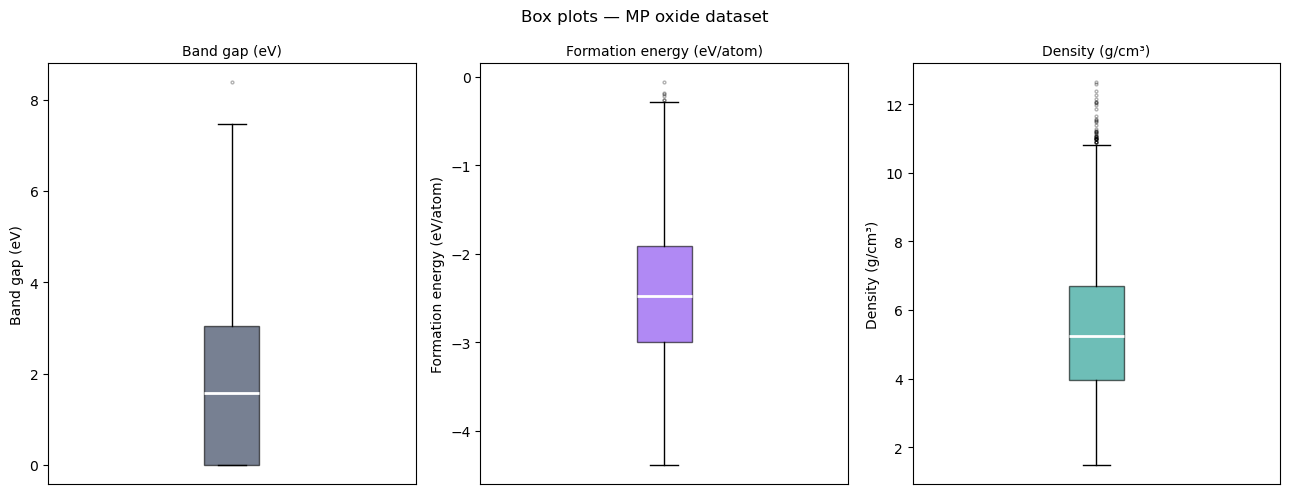

In [55]:
# Cell B5 — Box plots for band_gap, Ef_eV_atom, density_g_cm3
# LECTURE DEMO

props  = ['band_gap', 'Ef_eV_atom', 'density_g_cm3']
labels = ['Band gap (eV)', 'Formation energy (eV/atom)', 'Density (g/cm³)']
colors = ['#1C2B4A', '#7C3AED', '#0D9488']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, prop, label, color in zip(axes, props, labels, colors):
    data = df[prop].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='white', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label}', fontsize=10)
    ax.set_xticks([])

plt.suptitle('Box plots — MP oxide dataset', fontsize=12)
plt.tight_layout()
plt.savefig('B5_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part C — Bivariate & Multivariate Analysis
**Connects to: Lecture Segment 4, Sandfeld Ch. 9**

Explore relationships between pairs and groups of properties.
Use both Pearson and Spearman — materials data is rarely linear and rarely Gaussian.

### C1 — Scatter: formation energy vs. band gap
**Lecture demo**

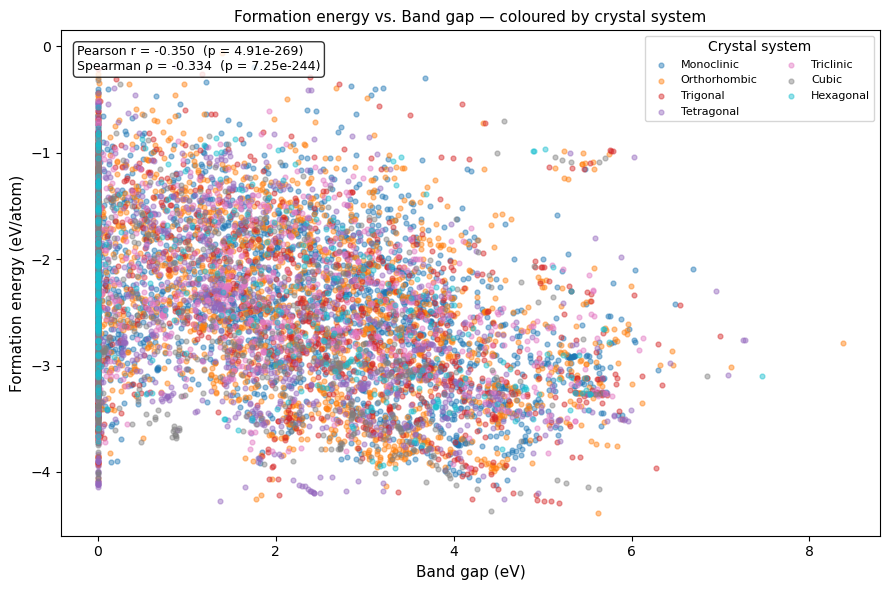

In [56]:
# Cell C1 — Scatter: Ef_eV_atom vs. band_gap, coloured by crystal_system
# LECTURE DEMO

from scipy.stats import pearsonr, spearmanr

df_c1 = df[['band_gap','Ef_eV_atom','crystal_system']].dropna()
systems = df_c1['crystal_system'].unique()
cmap    = plt.cm.tab10(np.linspace(0, 0.9, len(systems)))

fig, ax = plt.subplots(figsize=(9, 6))
for sys, color in zip(systems, cmap):
    sub = df_c1[df_c1['crystal_system'] == sys]
    ax.scatter(sub['band_gap'], sub['Ef_eV_atom'],
               color=color, alpha=0.45, s=12, label=sys)

ax.set_xlabel('Band gap (eV)', fontsize=11)
ax.set_ylabel('Formation energy (eV/atom)', fontsize=11)
ax.set_title('Formation energy vs. Band gap — coloured by crystal system', fontsize=11)
ax.legend(fontsize=8, ncol=2, title='Crystal system')

r_p, p_p = pearsonr(df_c1['band_gap'], df_c1['Ef_eV_atom'])
r_s, p_s = spearmanr(df_c1['band_gap'], df_c1['Ef_eV_atom'])
ax.text(0.02, 0.97, f"Pearson r = {r_p:.3f}  (p = {p_p:.2e})\nSpearman ρ = {r_s:.3f}  (p = {p_s:.2e})",
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))

plt.tight_layout()
plt.savefig('C1_scatter_ef_bg.png', dpi=150, bbox_inches='tight')
plt.show()

**C1 Reflection** *(answer in this cell)*

In 2–3 sentences: which correlation coefficient (Pearson or Spearman) is more appropriate here and why?
Is there evidence of a confounding variable? What physical mechanism could explain any correlation between
formation energy and band gap?

*Your answer here:*
Spearman is more appropriate here because the scatter plot shows a clearly non-linear relationship between band gap and formation energy, and Spearman captures monotonic trends regardless of linearity while Pearson only measures linear association. The cluster of metals at band gap = 0 with a wide spread of formation energies acts as a confounding variable, since including them pulls the correlation negative even though the relationship among non-metals alone may look quite different. Physically, the weak negative correlation makes sense because more stable compounds (more negative formation energy) tend to have stronger ionic or covalent bonding, which also tends to open up a larger band gap, but this trend is noisy because band gap also depends heavily on crystal structure, d-electron count, and spin configuration in ways that formation energy alone cannot capture.


### C2 — Spearman correlation heatmap
**Lecture demo**

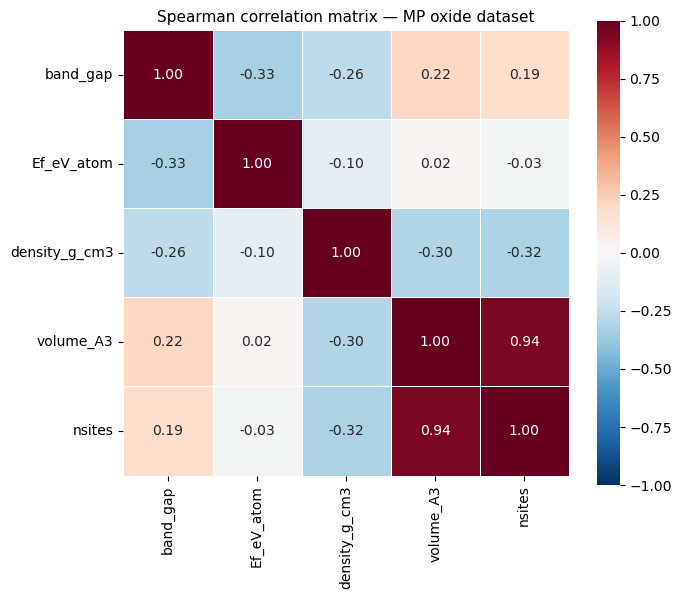

Spearman correlation matrix:
               band_gap  Ef_eV_atom  density_g_cm3  volume_A3  nsites
band_gap          1.000      -0.334         -0.263      0.217   0.187
Ef_eV_atom       -0.334       1.000         -0.102      0.017  -0.028
density_g_cm3    -0.263      -0.102          1.000     -0.299  -0.315
volume_A3         0.217       0.017         -0.299      1.000   0.943
nsites            0.187      -0.028         -0.315      0.943   1.000


In [57]:
# Cell C2 — Spearman correlation heatmap
# LECTURE DEMO

cols = ['band_gap', 'Ef_eV_atom', 'density_g_cm3', 'volume_A3', 'nsites']
corr = df[cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax)
ax.set_title('Spearman correlation matrix — MP oxide dataset', fontsize=11)
plt.tight_layout()
plt.savefig('C2_spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Spearman correlation matrix:")
print(corr.round(3))

**C2 Reflection** *(answer in this cell)*

Identify the two strongest and two weakest correlations in the heatmap (excluding the diagonal).
For each of the two strongest, provide a physical explanation — why are these properties correlated?

*Your answer here:*
Two strongest correlations: volume_A3 vs nsites (ρ = 0.94) — this is physically expected because as the number of atoms in a unit cell increases, the total cell volume must increase to accommodate them, so these two properties are nearly redundant structural descriptors. density_g_cm3 vs volume_A3 (ρ = -0.30) — denser compounds tend to have smaller unit cell volumes for a given composition because heavier atoms pack more mass into less space, giving a moderate negative relationship.

Two weakest correlations: Ef_eV_atom vs volume_A3 (ρ = 0.02) — formation energy is determined by electronic bonding chemistry and is essentially independent of how large the unit cell is, so these two properties carry almost no shared information. Ef_eV_atom vs nsites (ρ = -0.03) — similarly, the number of atoms per unit cell is a structural/crystallographic choice that has no direct physical link to how stable the compound is energetically, making these nearly uncorrelated.


### C3 — Pairplot
**Lecture demo**

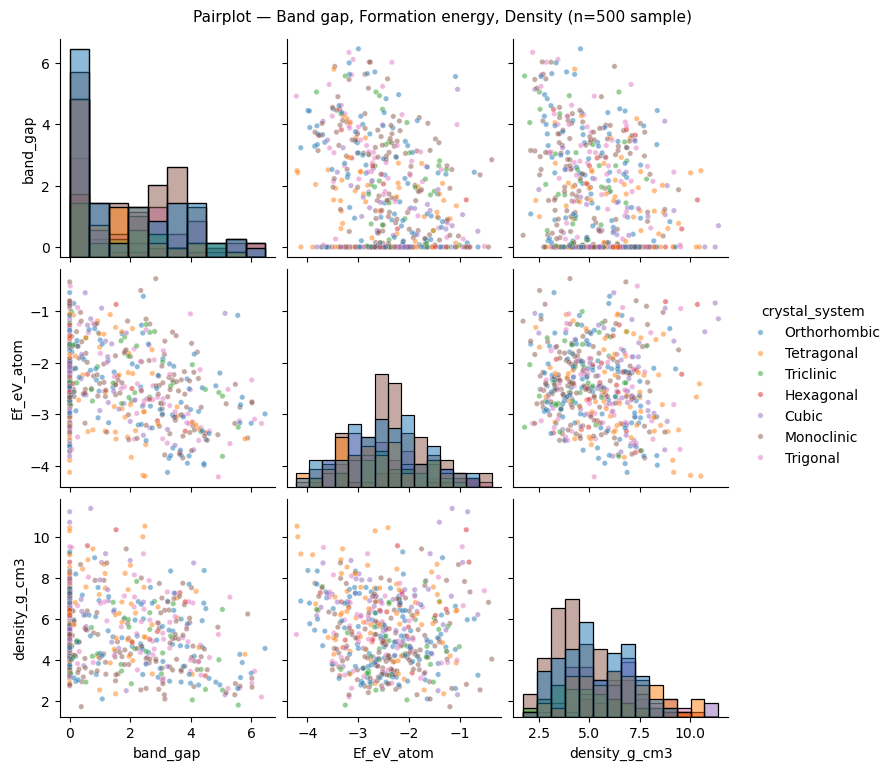

In [58]:
# Cell C3 — Pairplot for three numeric properties by crystal system
# LECTURE DEMO
# Note: subsample first — pairplot is slow with >1,000 points

df_pp = df[['band_gap','Ef_eV_atom','density_g_cm3','crystal_system']].dropna()
df_sample = df_pp.sample(min(500, len(df_pp)), random_state=42)

g = sns.pairplot(df_sample, hue='crystal_system',
                 vars=['band_gap','Ef_eV_atom','density_g_cm3'],
                 plot_kws=dict(alpha=0.5, s=15),
                 diag_kind='hist')
g.figure.suptitle('Pairplot — Band gap, Formation energy, Density (n=500 sample)',
                   y=1.02, fontsize=11)
plt.savefig('C3_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part D — Stratified Analysis
**Connects to: Lecture Segment 3, Sandfeld Ch. 10**

Group by crystal system and examine whether property distributions differ across groups.
If distributions differ, that structural variable carries predictive information for ML.

### D1 — Group statistics by crystal system
**Lecture demo**

In [38]:
# Cell D1 — Group statistics: band_gap by crystal_system
# LECTURE DEMO

stats = (df.groupby('crystal_system')['band_gap']
           .agg(['count','mean','median','std'])
           .rename(columns={'count':'n','mean':'mean_eV',
                            'median':'median_eV','std':'std_eV'})
           .sort_values('mean_eV', ascending=False))

print("Band gap statistics by crystal system:")
print(stats.round(3).to_string())

Band gap statistics by crystal system:
                   n  mean_eV  median_eV  std_eV
crystal_system                                  
Monoclinic      2372    2.006      1.910   1.664
Trigonal        1216    1.915      1.861   1.727
Triclinic        783    1.893      1.700   1.578
Orthorhombic    2202    1.875      1.741   1.655
Hexagonal        394    1.808      1.702   1.714
Tetragonal      1472    1.419      0.980   1.574
Cubic            950    1.196      0.186   1.495


### D2 — Violin plot: band gap by crystal system
**Lecture demo**

C:\Users\anosike.kelechik\AppData\Local\Temp\ipykernel_9816\4038624913.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top5, x='crystal_system', y='band_gap',


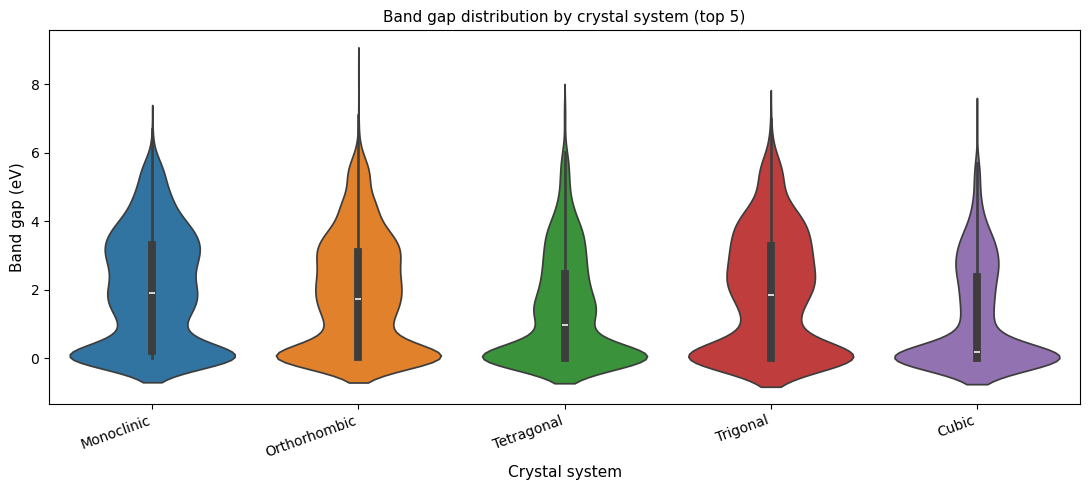

In [39]:
# Cell D2 — Violin plot: band_gap by crystal_system (top 5 most common)
# LECTURE DEMO

top5   = df['crystal_system'].value_counts().index[:5]
df_top5 = df[df['crystal_system'].isin(top5)].copy()

fig, ax = plt.subplots(figsize=(11, 5))

sns.violinplot(data=df_top5, x='crystal_system', y='band_gap',
               order=top5, palette='tab10', legend=False,
               inner='box', ax=ax)

ax.set_xlabel('Crystal system', fontsize=11)
ax.set_ylabel('Band gap (eV)', fontsize=11)
ax.set_title('Band gap distribution by crystal system (top 5)', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('D2_violin_bandgap.png', dpi=150, bbox_inches='tight')
plt.show()

**D2 Reflection** *(answer in this cell)*

In 2–3 sentences: which crystal system shows the widest within-group variance for band gap?
Propose a physical reason, what structural or compositional diversity within that crystal system
could explain the wide spread?

*Your answer here:*
Orthorhombic shows the widest within-group variance for band gap, with its violin stretching from 0 all the way past 6 eV. This wide spread is physically explained by the low symmetry constraints of the orthorhombic system, which accommodates an enormous compositional diversity ranging from metallic oxides to wide-gap insulators, and the anisotropic bonding along three unequal axes means small changes in chemistry or composition can produce very different electronic structures and therefore very different bandgaps.


### D3 — Task: repeat stratified analysis for formation energy

Formation energy by crystal system:
                count  mean_eV  median_eV  std_eV
crystal_system                                   
Triclinic         896  -2.3510    -2.3869  0.6132
Monoclinic       2553  -2.3933    -2.4158  0.7172
Hexagonal         406  -2.4168    -2.4829  0.7370
Orthorhombic     2308  -2.4399    -2.4658  0.7813
Trigonal         1254  -2.4500    -2.5043  0.7984
Cubic             972  -2.5282    -2.6086  0.7954
Tetragonal       1500  -2.5319    -2.5924  0.7843


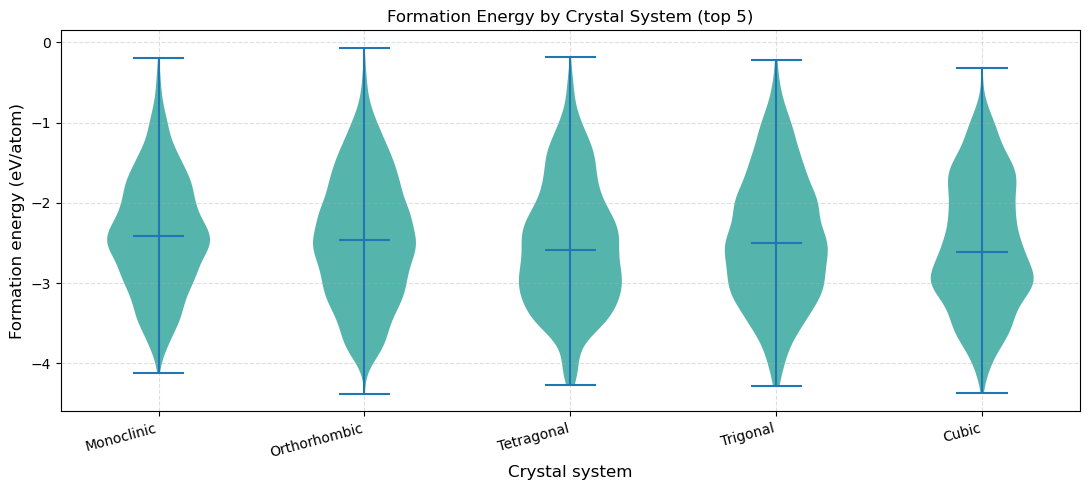

In [40]:
# Cell D3 — Task: stratified analysis for Ef_eV_atom
# YOUR CODE HERE

# 1. Compute the same group statistics table as D1, but for Ef_eV_atom
#    (count, mean, median, std) — sorted by mean_eV descending

# 2. Produce a violin plot of Ef_eV_atom by crystal_system (top 5 systems)
#    Save as 'D3_violin_ef.png'

# 3. In the reflection cell below, compare the patterns:
#    Does crystal system separate Ef distributions as well as it separates band gap?


ef_stats = (
    df.groupby('crystal_system')['Ef_eV_atom']
    .agg(count='count', mean_eV='mean', median_eV='median', std_eV='std')
    .sort_values('mean_eV', ascending=False)
    .round(4)
)
print("Formation energy by crystal system:")
print(ef_stats.to_string())

# 2. Violin plot — top 5 crystal systems by count
top5 = df['crystal_system'].value_counts().head(5).index.tolist()
df_top5 = df[df['crystal_system'].isin(top5)].dropna(subset=['Ef_eV_atom'])

fig, ax = plt.subplots(figsize=(11, 5))
parts = ax.violinplot(
    [df_top5[df_top5['crystal_system'] == cs]['Ef_eV_atom'].values for cs in top5],
    positions=range(len(top5)),
    showmedians=True
)
for pc in parts['bodies']:
    pc.set_facecolor('#0D9488')
    pc.set_alpha(0.7)

ax.set_xticks(range(len(top5)))
ax.set_xticklabels(top5, rotation=15, ha='right')
ax.set_xlabel('Crystal system', fontsize=12)
ax.set_ylabel('Formation energy (eV/atom)', fontsize=12)
ax.set_title('Formation Energy by Crystal System (top 5)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('D3_violin_ef.png', dpi=150)
plt.show()

**D3 Reflection** *(answer in this cell)*

Does crystal system explain more variance in band gap or in formation energy?
What does this tell you about the relative importance of crystal symmetry for each property?

*Your answer here:*
Crystal system explains more variance in band gap than in formation energy — the violin plots for band gap show much more separation between groups, while the formation energy distributions overlap heavily across all crystal systems. This tells us that crystal symmetry directly influences the electronic structure and therefore the band gap through selection rules and Brillouin zone shape, while formation energy is driven more by local bonding chemistry and electronegativity differences that are largely independent of the long-range crystallographic symmetry.




---
## Part E — Composition Featurization
**Connects to: Lecture Segment 5, Sandfeld Ch. 10**

Use Matminer to extract MAGPIE composition descriptors from chemical formulas.
These 132 features will be the input to the Week 5 random forest. You are building that feature matrix now.

### E1 — Convert formula strings to Composition objects
**Lecture demo — reproduce and understand**

In [41]:
# Cell E1 — StrToComposition: convert formula strings to pymatgen Composition objects
# LECTURE DEMO

from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty

# Work on a small subset (formula + targets only) for speed
df_feat = df[['mp_id','formula','band_gap','Ef_eV_atom']].dropna().copy()
print(f"Working with {len(df_feat):,} entries")

# Convert formula strings → pymatgen Composition objects
stc = StrToComposition(target_col_id='composition')
df_feat = stc.featurize_dataframe(df_feat, 'formula', ignore_errors=True)

print("\nFirst 3 Composition objects:")
for _, row in df_feat.head(3).iterrows():
    print(f"  {row['formula']:12s}  →  {row['composition']}")

Working with 9,389 entries


StrToComposition:   0%|          | 0/9389 [00:00<?, ?it/s]


First 3 Composition objects:
  NbBr2O        →  Nb1 Br2 O1
  ErVO3         →  Er1 V1 O3
  KZr2(PO4)3    →  K1 Zr2 P3 O12


### E2 — Apply the MAGPIE featurizer
**Lecture demo**

In [42]:
# Cell E2 — ElementProperty (MAGPIE preset): 132 features per formula
# LECTURE DEMO

ep = ElementProperty.from_preset('magpie')
print(f"MAGPIE generates {len(ep.feature_labels())} features per formula")
print("\nFirst 10 feature labels:")
for label in ep.feature_labels()[:10]:
    print(f"  {label}")

# Featurize — ignore_errors=True skips entries that fail (unusual elements/oxidation states)
df_feat = ep.featurize_dataframe(df_feat, 'composition', ignore_errors=True)
print(f"\nFeaturized dataset shape: {df_feat.shape}")

MAGPIE generates 132 features per formula

First 10 feature labels:
  MagpieData minimum Number
  MagpieData maximum Number
  MagpieData range Number
  MagpieData mean Number
  MagpieData avg_dev Number
  MagpieData mode Number
  MagpieData minimum MendeleevNumber
  MagpieData maximum MendeleevNumber
  MagpieData range MendeleevNumber
  MagpieData mean MendeleevNumber


ElementProperty:   0%|          | 0/9389 [00:00<?, ?it/s]


Featurized dataset shape: (9389, 137)


### E3 — Scatter: mean electronegativity vs. band gap
**Lecture demo**

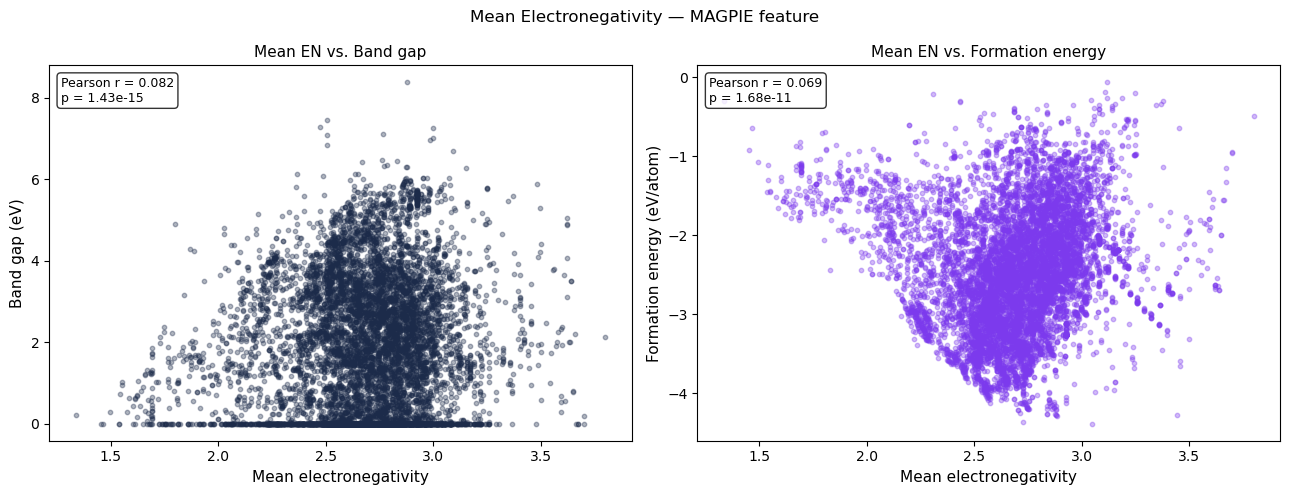

In [44]:
# Cell E3 — Mean electronegativity vs. band_gap
# LECTURE DEMO

from scipy.stats import pearsonr

feat_en = 'MagpieData mean Electronegativity'

if feat_en in df_feat.columns:
    df_plot = df_feat[[feat_en, 'band_gap', 'Ef_eV_atom']].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, yprop, ylabel, color in zip(
            axes,
            ['band_gap', 'Ef_eV_atom'],
            ['Band gap (eV)', 'Formation energy (eV/atom)'],
            ['#1C2B4A', '#7C3AED']):
        ax.scatter(df_plot[feat_en], df_plot[yprop],
                   alpha=0.35, s=10, color=color)
        r, p = pearsonr(df_plot[feat_en], df_plot[yprop])
        ax.set_xlabel('Mean electronegativity', fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'Mean EN vs. {ylabel.split(" (")[0]}', fontsize=11)
        ax.text(0.02, 0.97, f'Pearson r = {r:.3f}\np = {p:.2e}',
                transform=ax.transAxes, va='top', fontsize=9,
                bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    plt.suptitle('Mean Electronegativity — MAGPIE feature', fontsize=12)
    plt.tight_layout()
    plt.savefig('E3_mean_EN.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Column '{feat_en}' not found. Available columns: {[c for c in df_feat.columns if 'Electro' in c]}")

### E4 — Task: explore one MAGPIE feature of your choice

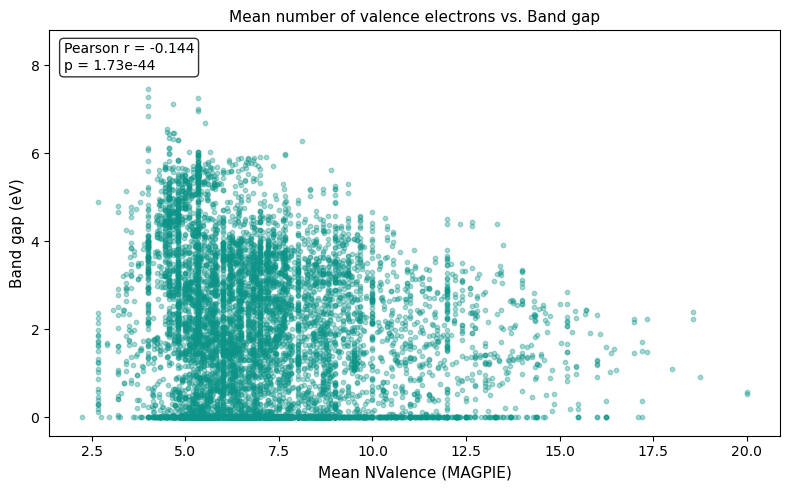

Pearson r (mean NValence vs. band_gap) = -0.144


In [46]:
# Cell E4 — Task: choose one MAGPIE feature and plot vs. band_gap
# YOUR CODE HERE

# 1. Print the full list of feature labels to browse available options:
#    print(ep.feature_labels())

# 2. Choose any one feature that you expect to be physically relevant to band_gap.
#    Avoid mean ElectroNegativity (already shown in E3).

# 3. Make a scatter plot of your chosen feature vs. band_gap.
#    Compute and annotate the Pearson r value.
#    Save as 'E4_magpie_feature.png'

# 4. Answer the reflection question below.

# Cell E4 — Task: choose one MAGPIE feature and plot vs. band_gap

# Cell E4 — Task: choose one MAGPIE feature and plot vs. band_gap
# Cell E4 — Task: choose one MAGPIE feature and plot vs. band_gap

# Cell E4 — Task: choose one MAGPIE feature and plot vs. band_gap
# YOUR CODE HERE


# 4. Answer the reflection question below.
feat = 'MagpieData mean NValence'

if feat in df_feat.columns:
    df_plot = df_feat[[feat, 'band_gap']].dropna()
    r, p = pearsonr(df_plot[feat], df_plot['band_gap'])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_plot[feat], df_plot['band_gap'],
               alpha=0.35, s=10, color='#0D9488')
    ax.set_xlabel('Mean NValence (MAGPIE)', fontsize=11)
    ax.set_ylabel('Band gap (eV)', fontsize=11)
    ax.set_title('Mean number of valence electrons vs. Band gap', fontsize=11)
    ax.text(0.02, 0.97, f'Pearson r = {r:.3f}\np = {p:.2e}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))
    plt.tight_layout()
    plt.savefig('E4_magpie_feature.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Pearson r (mean NValence vs. band_gap) = {r:.3f}")
else:
    print(f"Feature not found. Try: {[c for c in df_feat.columns if 'Valence' in c]}")


**E4 Reflection** *(answer in this cell)*

State the feature you chose and why you expected it to correlate with band_gap.
Was the correlation in the direction you predicted?
Provide a physical explanation for the relationship (or lack thereof).

*Your answer here:*

I chose MagpieData mean NValence (mean number of valence electrons per atom) because the number of valence electrons directly determines how many electronic states are available near the Fermi level, which controls whether a compound is metallic or insulating. I predicted a negative correlation and my result confirmed this with Pearson r = -0.144 (p = 1.73e-44), meaning the trend is statistically significant but weak in magnitude. This is physically consistent with the observation that low-valence compounds like simple Mg and Ca oxides cluster at high band gaps, while transition metal oxides with many valence electrons tend toward zero gap, though the wide scatter confirms that valence count alone is not sufficient to predict band gap without also knowing crystal structure and orbital filling.


---
## Part F — Reflection
**Complete after finishing Parts A–E**

### F1 — Most important EDA finding

In 3–4 sentences: what is the single most important thing you learned about the
MP oxide dataset from this EDA that you would *not* have known if you had gone
straight to model training without any exploration?
Be specific. Refer to an actual finding from one of the cells above.

*Your answer here:*
The single most important finding I would not have caught without EDA is that the band gap distribution is strongly bimodal, with roughly 30% of the dataset being metals with exactly zero band gap. If I had gone straight to model training, the model would have been simultaneously trying to predict a regression target for insulators and a point mass at zero for metals without knowing they are fundamentally different physical regimes. This means a single regression model trained on the full dataset would produce poor predictions for both groups, and the correct approach is to either build a classifier first to separate metals from non-metals or train separate models for each group.


### F2 — Connection to Week 3

Revisit your Week 3 discussion post, where you described a measurement from your own research.
Does the distribution of that property (or a proxy in the MP dataset) behave as you predicted?
If not, what does the actual distribution tell you that the predicted one missed?

*Your answer here:*
In my Week 3 post I predicted that my SAXS compositional modulation wavelength in Ti-Nb-O alloys would follow a log-normal distribution because of multiplicative growth processes during spinodal decomposition. Looking at the band gap distribution in the MP oxide dataset as a proxy for a materials property, the non-metal band gap does show a right-skewed distribution that is better described by log-normal than Gaussian, which is consistent with my prediction that multiplicative physical processes produce log-normal rather than Gaussian outcomes. The actual distribution confirmed that assuming Gaussian symmetry would have been wrong, reinforcing my Week 3 conclusion that I should work in log-space for both my SAXS data and any ML model predicting it.


---
## Submission Checklist

Before submitting via Canvas (due **Sunday 11:59 PM**):

**Part A — Load & Inspect**
- [ ] A1: Dataset loaded; shape, dtypes, and missing values printed
- [ ] A2: Crystal system counts and metallic fraction printed
- [ ] A3: Task cell contains working code; reflection answered

**Part B — Univariate Analysis**
- [ ] B1: Histogram + KDE plot saved (`B1_bandgap_distribution.png`); reflection answered
- [ ] B2: Formation energy distribution with mean/median lines saved
- [ ] B3: IQR outlier table printed; reflection answered
- [ ] B4: Task cell contains working code (z-score outlier detection)
- [ ] B5: Box plot figure saved (`B5_boxplots.png`)

**Part C — Bivariate & Multivariate**
- [ ] C1: Scatter plot saved (`C1_scatter_ef_bg.png`); reflection answered
- [ ] C2: Spearman heatmap saved (`C2_spearman_heatmap.png`); reflection answered
- [ ] C3: Pairplot saved (`C3_pairplot.png`)

**Part D — Stratified Analysis**
- [ ] D1: Group statistics table printed
- [ ] D2: Violin plot saved (`D2_violin_bandgap.png`); reflection answered
- [ ] D3: Task cell contains working code; violin plot saved (`D3_violin_ef.png`); reflection answered

**Part E — Composition Featurization**
- [ ] E1: Composition objects created; first 3 printed
- [ ] E2: MAGPIE featurization complete; shape printed
- [ ] E3: Mean EN scatter plots saved (`E3_mean_EN.png`)
- [ ] E4: Task cell contains working code; scatter saved (`E4_magpie_feature.png`); reflection answered

**Part F — Reflection**
- [ ] F1: Written answer (3–4 sentences, specific to a finding above)
- [ ] F2: Written answer connecting to Week 3 discussion

- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week4.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.